In [ ]:
# 1. Mount Google Drive to access your saved CSV
from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


# load generated report by VLM in test set

In [ ]:
import pandas as pd

# Define the path to your saved reports
file_path = "/content/drive/MyDrive/msc_final_evaluation_reports.csv"
print(f"Loading generated reports from: {file_path}")

# Load the dataframe
df = pd.read_csv(file_path)


all_generated_reports = df['generated_report'].fillna("normal").tolist()
all_reference_reports = df['reference_report'].fillna("normal").tolist()

print(f"✅ Successfully loaded {len(all_generated_reports)} reports into memory.")

Loading generated reports from: /content/drive/MyDrive/msc_final_evaluation_reports_before.csv
✅ Successfully loaded 606 reports into memory.


# 4-State Macro-F1 Score

In [ ]:
import torch
import numpy as np
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import f1_score
from tqdm import tqdm

print("Downloading Clinical Assertion BERT...")
model_name = "bvanaken/clinical-assertion-negation-bert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

pathologies = [
    "cardiomegaly", "opacity", "consolidation", "edema",
    "pleural effusion", "pneumothorax", "atelectasis", "fracture", "pneumonia"
]

def extract_4_state_labels(reports):
    """
    States: 0 (Absent/Negative), 1 (Present/Positive), 2 (Possible/Uncertain), 3 (Blank/Not Mentioned)
    """
    matrix = []

    for text in tqdm(reports, desc="Running Neural Labeler"):
        # Split report into sentences for accurate BERT processing
        sentences = str(text).lower().replace('.', '. ').split('. ')
        patient_states = []

        for pathology in pathologies:
            state = 3 # Default to Blank

            # Find the specific sentence containing the disease
            for sentence in sentences:
                if pathology in sentence:
                    inputs = tokenizer(sentence, return_tensors="pt", truncation=True, max_length=128).to(device)
                    with torch.no_grad():
                        outputs = model(**inputs)
                        # The model outputs: 0=ABSENT, 1=PRESENT, 2=POSSIBLE
                        state = torch.argmax(outputs.logits, dim=1).item()
                    break # Stop looking once we find the disease mention

            patient_states.append(state)
        matrix.append(patient_states)

    return np.array(matrix)

print("\nExtracting Ground Truth Labels...")
y_true = extract_4_state_labels(all_reference_reports)

print("\nExtracting Generated Model Labels...")
y_pred = extract_4_state_labels(all_generated_reports)

# Flatten matrices to calculate macro-F1 across all 4 states for all diseases simultaneously
y_true_flat = y_true.flatten()
y_pred_flat = y_pred.flatten()

# Macro-F1 treats the "Blank" and "Negative" classes as just as important as the "Positive" class!
macro_f1 = f1_score(y_true_flat, y_pred_flat, average='macro', zero_division=0)

print("\n" + "="*50)
print("🔬 4-STATE NEURAL LABELER 🔬")
print("="*50)
print(f"4-State Macro-F1 Score: {macro_f1:.4f}")
print("="*50)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/819 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Extracting Ground Truth Labels...


Running Neural Labeler: 100%|██████████| 606/606 [00:12<00:00, 48.00it/s]



Extracting Generated Model Labels...


Running Neural Labeler: 100%|██████████| 606/606 [00:11<00:00, 50.89it/s]



🔬 4-STATE NEURAL LABELER 🔬
4-State Macro-F1 Score: 0.4802


# METEO Score

In [ ]:
import pandas as pd
import nltk
from nltk.translate.meteor_score import meteor_score
from tqdm import tqdm

# ==========================================
# 1. DOWNLOAD NLTK DICTIONARIES
# ==========================================
# METEOR requires these specific packages to tokenize and understand synonyms
for pkg in ['punkt', 'punkt_tab', 'wordnet', 'omw-1.4']:
    nltk.download(pkg, quiet=True)

# ==========================================
# 2. LOAD SECURED DATA
# ==========================================
file_path = "/content/drive/MyDrive/msc_final_evaluation_reports.csv"
print(f"Loading generated reports from: {file_path}")

df = pd.read_csv(file_path)
all_generated_reports = df['generated_report'].fillna("normal").tolist()
all_reference_reports = df['reference_report'].fillna("normal").tolist()

print(f"✅ Successfully loaded {len(all_generated_reports)} reports.")

# ==========================================
# 3. CALCULATE METEOR
# ==========================================
print("\nCalculating METEOR Score...")
meteor_scores = []

for gen, ref in zip(tqdm(all_generated_reports), all_reference_reports):
    # Both strings must be tokenized into individual words first
    ref_tokens = nltk.word_tokenize(str(ref).lower())
    gen_tokens = nltk.word_tokenize(str(gen).lower())

    # METEOR expects a list of references
    score = meteor_score([ref_tokens], gen_tokens)
    meteor_scores.append(score)

avg_meteor = sum(meteor_scores) / len(meteor_scores)

# ==========================================
# 4. FINAL OUTPUT
# ==========================================
print("\n" + "="*50)
print(f"🌠 AVERAGE METEOR SCORE: {avg_meteor:.4f}")
print("="*50)

Loading generated reports from: /content/drive/MyDrive/msc_final_evaluation_reports_before.csv
✅ Successfully loaded 606 reports.

Calculating METEOR Score...


100%|██████████| 606/606 [00:05<00:00, 114.80it/s]


🌠 AVERAGE METEOR SCORE: 0.3403


# CIDEr

In [ ]:
!pip install pycocoevalcap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.3/104.3 MB 9.5 MB/s eta 0:00:00


In [ ]:
!pip install -U bitsandbytes accelerate peft pycocoevalcap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.5 MB/s eta 0:00:00


In [ ]:
import os
import torch
import torch.nn as nn
import pandas as pd
from tqdm import tqdm
from pycocoevalcap.cider.cider import Cider
from datasets import load_dataset
from transformers import AutoImageProcessor, AutoModel, AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from peft import PeftModel


print("Loading Dataset and isolating the Holdout Test Set...")
device = "cuda" if torch.cuda.is_available() else "cpu"

#  MUST use the same test_size and random seed (42) so the split matches the training run perfectly.
full_dataset = load_dataset("Shrey-1329/cxiu_hf_dataset", split="train")
train_test_split = full_dataset.train_test_split(test_size=0.2, seed=42)
val_test_split = train_test_split['test'].train_test_split(test_size=0.5, seed=42)
test_split = val_test_split['test'] # The untouched 10%

print(f"Test Set Ready: {len(test_split)} images.\n")

# ==========================================
# 2. LOAD ARCHITECTURE & TRAINED WEIGHTS
# ==========================================
print("Loading Architecture and Final Weights...")

FINAL_CHECKPOINT_DIR = "/content/drive/MyDrive/msc_medical_vlm_weights_final/checkpoint-epoch-6"

# A. Vision Encoder
vision_processor = AutoImageProcessor.from_pretrained("microsoft/rad-dino")
vision_encoder = AutoModel.from_pretrained("microsoft/rad-dino").to(device)
vision_encoder.eval()

# B. LLM (Qwen2.5) with LoRA Adapters
llm_id = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(llm_id)
tokenizer.pad_token = tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16 # Matching our T4 optimization
)
base_llm = AutoModelForCausalLM.from_pretrained(llm_id, quantization_config=bnb_config, device_map={"": 0})

print("Loading trained LoRA adapters...")
efficient_llm = PeftModel.from_pretrained(base_llm, os.path.join(FINAL_CHECKPOINT_DIR, "qwen_lora_adapters"))
efficient_llm.eval()

# C. Q-Former Projector
class QFormerProjector(nn.Module):
    def __init__(self, num_queries=64, vision_dim=768, llm_dim=3584):
        super().__init__()
        self.query_tokens = nn.Parameter(torch.randn(1, num_queries, vision_dim))
        self.cross_attn = nn.MultiheadAttention(embed_dim=vision_dim, num_heads=8, batch_first=True)
        self.norm1 = nn.LayerNorm(vision_dim)
        self.ffn = nn.Sequential(nn.Linear(vision_dim, vision_dim * 4), nn.GELU(), nn.Linear(vision_dim * 4, vision_dim))
        self.norm2 = nn.LayerNorm(vision_dim)
        self.proj = nn.Linear(vision_dim, llm_dim)
        self.llm_norm = nn.LayerNorm(llm_dim)

    def forward(self, patch_embeddings):
        spatial_patches = patch_embeddings[:, 1:, :]
        batch_size = spatial_patches.shape[0]
        queries = self.query_tokens.expand(batch_size, -1, -1)
        attn_output, _ = self.cross_attn(query=queries, key=spatial_patches, value=spatial_patches)
        x = self.norm1(queries + attn_output)
        x = self.norm2(x + self.ffn(x))
        return self.llm_norm(self.proj(x))

print("Loading trained Q-Former Projector...")
projector = QFormerProjector(num_queries=64, vision_dim=768, llm_dim=efficient_llm.config.hidden_size).to(device)
projector.load_state_dict(torch.load(os.path.join(FINAL_CHECKPOINT_DIR, "vision_projector.pth"), map_location=device, weights_only=True))
projector.eval()

# ==========================================
# 3. TEST SET EVALUATION LOOP
# ==========================================
print("\nInitiating Test Set Evaluation...")

gts = {} # Ground Truths
res = {} # Model Results
csv_data = []

with torch.no_grad():
    for i, example in enumerate(tqdm(test_split, desc="Evaluating Test Set")):
        img_id = f"test_img_{i}"

        # Extract Ground Truth
        ground_truth_report = example.get('text', "Normal.")
        gts[img_id] = [ground_truth_report]

        # Image Processing & Vision Forward Pass
        image = example['image'].convert("RGB")
        pixel_values = vision_processor(images=image, return_tensors="pt").pixel_values.to(device)

        with torch.amp.autocast(device_type="cuda", dtype=torch.float16):
            patch_embeddings = vision_encoder(pixel_values).last_hidden_state.to(torch.float16)
            visual_prefix = projector(patch_embeddings)

            # Text Prompt Setup
            messages = [
                {"role": "system", "content": "You are an expert radiologist. Write ONLY the diagnostic narrative."},
                {"role": "user", "content": "Analyze this chest radiograph and generate a concise clinical report."}
            ]
            prompt_text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            text_inputs = tokenizer(prompt_text, return_tensors="pt").to(device)

            # Concatenate and Generate
            text_embeds = efficient_llm.get_input_embeddings()(text_inputs.input_ids)
            inputs_embeds = torch.cat([visual_prefix, text_embeds], dim=1).to(torch.float16)

            visual_mask = torch.ones((1, 64), dtype=torch.long, device=device)
            attention_mask = torch.cat([visual_mask, text_inputs.attention_mask], dim=1)

            generated_ids = efficient_llm.generate(
                inputs_embeds=inputs_embeds,
                attention_mask=attention_mask,
                max_new_tokens=150,
                do_sample=False,
                repetition_penalty=1.1,
                pad_token_id=tokenizer.pad_token_id
            )

        # Decode and Save Result
        generated_report = tokenizer.decode(generated_ids[0], skip_special_tokens=True).strip()
        res[img_id] = [generated_report]

        csv_data.append({
            "image_id": img_id,
            "ground_truth": ground_truth_report,
            "generated_report": generated_report
        })

# ==========================================
# 4. METRIC CALCULATION & SAVING
# ==========================================
print("\nCalculating Official CIDEr Score...")
cider_scorer = Cider()
cider_score, individual_cider_scores = cider_scorer.compute_score(gts, res)

print(f"\n======================================")
print(f"🏆 FINAL TEST SET CIDEr SCORE: {cider_score:.4f}")
print(f"======================================")

# Save the predictions to CSV
df_results = pd.DataFrame(csv_data)
df_results['cider_score'] = individual_cider_scores

FINAL_CSV_PATH = "/content/drive/MyDrive/msc_medical_vlm_weights_final/test_set_predictions.csv"
df_results.to_csv(FINAL_CSV_PATH, index=False)
print(f"\n💾 Saved all generated reports and individual scores to: {FINAL_CSV_PATH}")

Loading Dataset and isolating the Holdout Test Set...


README.md:   0%|          | 0.00/1.87k [00:00<?, ?B/s]

data/train-00000-of-00003-34bea7eff0b2e4(…):   0%|          | 0.00/369M [00:00<?, ?B/s]

data/train-00001-of-00003-e264f8a8545640(…):   0%|          | 0.00/369M [00:00<?, ?B/s]

data/train-00002-of-00003-b727c3f3dd3884(…):   0%|          | 0.00/370M [00:00<?, ?B/s]

...

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loading trained LoRA adapters...
Loading trained Q-Former Projector...

Initiating Test Set Evaluation...


Evaluating Test Set:   0%|          | 0/606 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1113: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Evaluating Test Set: 100%|██████████| 606/606 [1:05:44<00:00,  6.51s/it]



Calculating Official CIDEr Score...

🏆 FINAL TEST SET CIDEr SCORE: 0.2677

💾 Saved all generated reports and individual scores to: /content/drive/MyDrive/msc_medical_vlm_weights_final/test_set_predictions.csv


# RadGraph

In [ ]:
!pip install radgraph
!pip install transformers torch

In [ ]:
!pip install -U torch==2.5.1 torchvision==0.20.1
!pip install radgraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.4/906.4 MB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 102.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 27.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 586.6 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

restart the session to run the following cell

In [ ]:
from radgraph import F1RadGraph

scorer = F1RadGraph(reward_level="all")

Using device: cuda:0
model_type not provided, defaulting to radgraph-xl


/usr/local/lib/python3.12/dist-packages/radgraph/radgraph.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_state = torch.load(model_state_path)


In [ ]:
from radgraph import F1RadGraph

scorer = F1RadGraph(reward_level="all")

hyp = hypotheses[0]
ref = references[0]

print("HYP:", hyp)
print("REF:", ref)

out = scorer([hyp], [ref])
print(out)

Using device: cuda:0
model_type not provided, defaulting to radgraph-xl
HYP: the heart size and pulmonary vascularity appear within normal limits the lungs are free of focal airspace disease no pleural effusion or pneumothorax is seen
REF: the heart size is normal with stable appearance of the cardiomediastinal silhouette the lungs are clear without focal airspace opacity pleural effusion or pneumothorax there are stable calcified right peritracheal lymph  the osseous structures are intact
((0.5454545454545455, 0.47058823529411764, 0.4571428571428571), ([0.5454545454545455], [0.47058823529411764], [0.4571428571428571]), [{'text': 'the heart size is normal with stable appearance of the cardiomediastinal silhouette the lungs are clear without focal airspace opacity pleural effusion or pneumothorax there are stable calcified right peritracheal lymph the osseous structures are intact', 'entities': {'1': {'tokens': 'heart', 'label': 'Anatomy::definitely present', 'start_ix': 1, 'end_ix': 1,

# RadGraph Precision ,recall and F1

In [ ]:
import pandas as pd
from radgraph import F1RadGraph

df = pd.read_csv(CSV_PATH)

hypotheses = df["generated_report"].fillna("").tolist()
references = df["ground_truth"].fillna("").tolist()

scorer = F1RadGraph(reward_level="all")

mean_reward, _, _, _ = scorer(hypotheses, references)

precision, recall, f1 = mean_reward

print("RadGraph Precision:", precision)
print("RadGraph Recall:", recall)
print("RadGraph F1:", f1)

Using device: cuda:0
model_type not provided, defaulting to radgraph-xl


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/radgraph/radgraph.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by t

RadGraph Precision: 0.3684563319025057
RadGraph Recall: 0.3222871246944255
RadGraph F1: 0.2694879511693718


# Graphs from all the metrics

/tmp/ipykernel_10029/3395227997.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Score', y='Metric', data=df_nlg, ax=ax1, palette='Blues_r')
/tmp/ipykernel_10029/3395227997.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Metric', y='Score', data=df_rad, ax=ax2, palette='crest')
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/tmp/ipykernel_10029/3395227997.py:80: FutureWarning: 

Passing `palette` without a

✅ Dashboard successfully generated and saved to: /content/drive/MyDrive/msc_medical_vlm_weights_final/thesis_results_dashboard.png


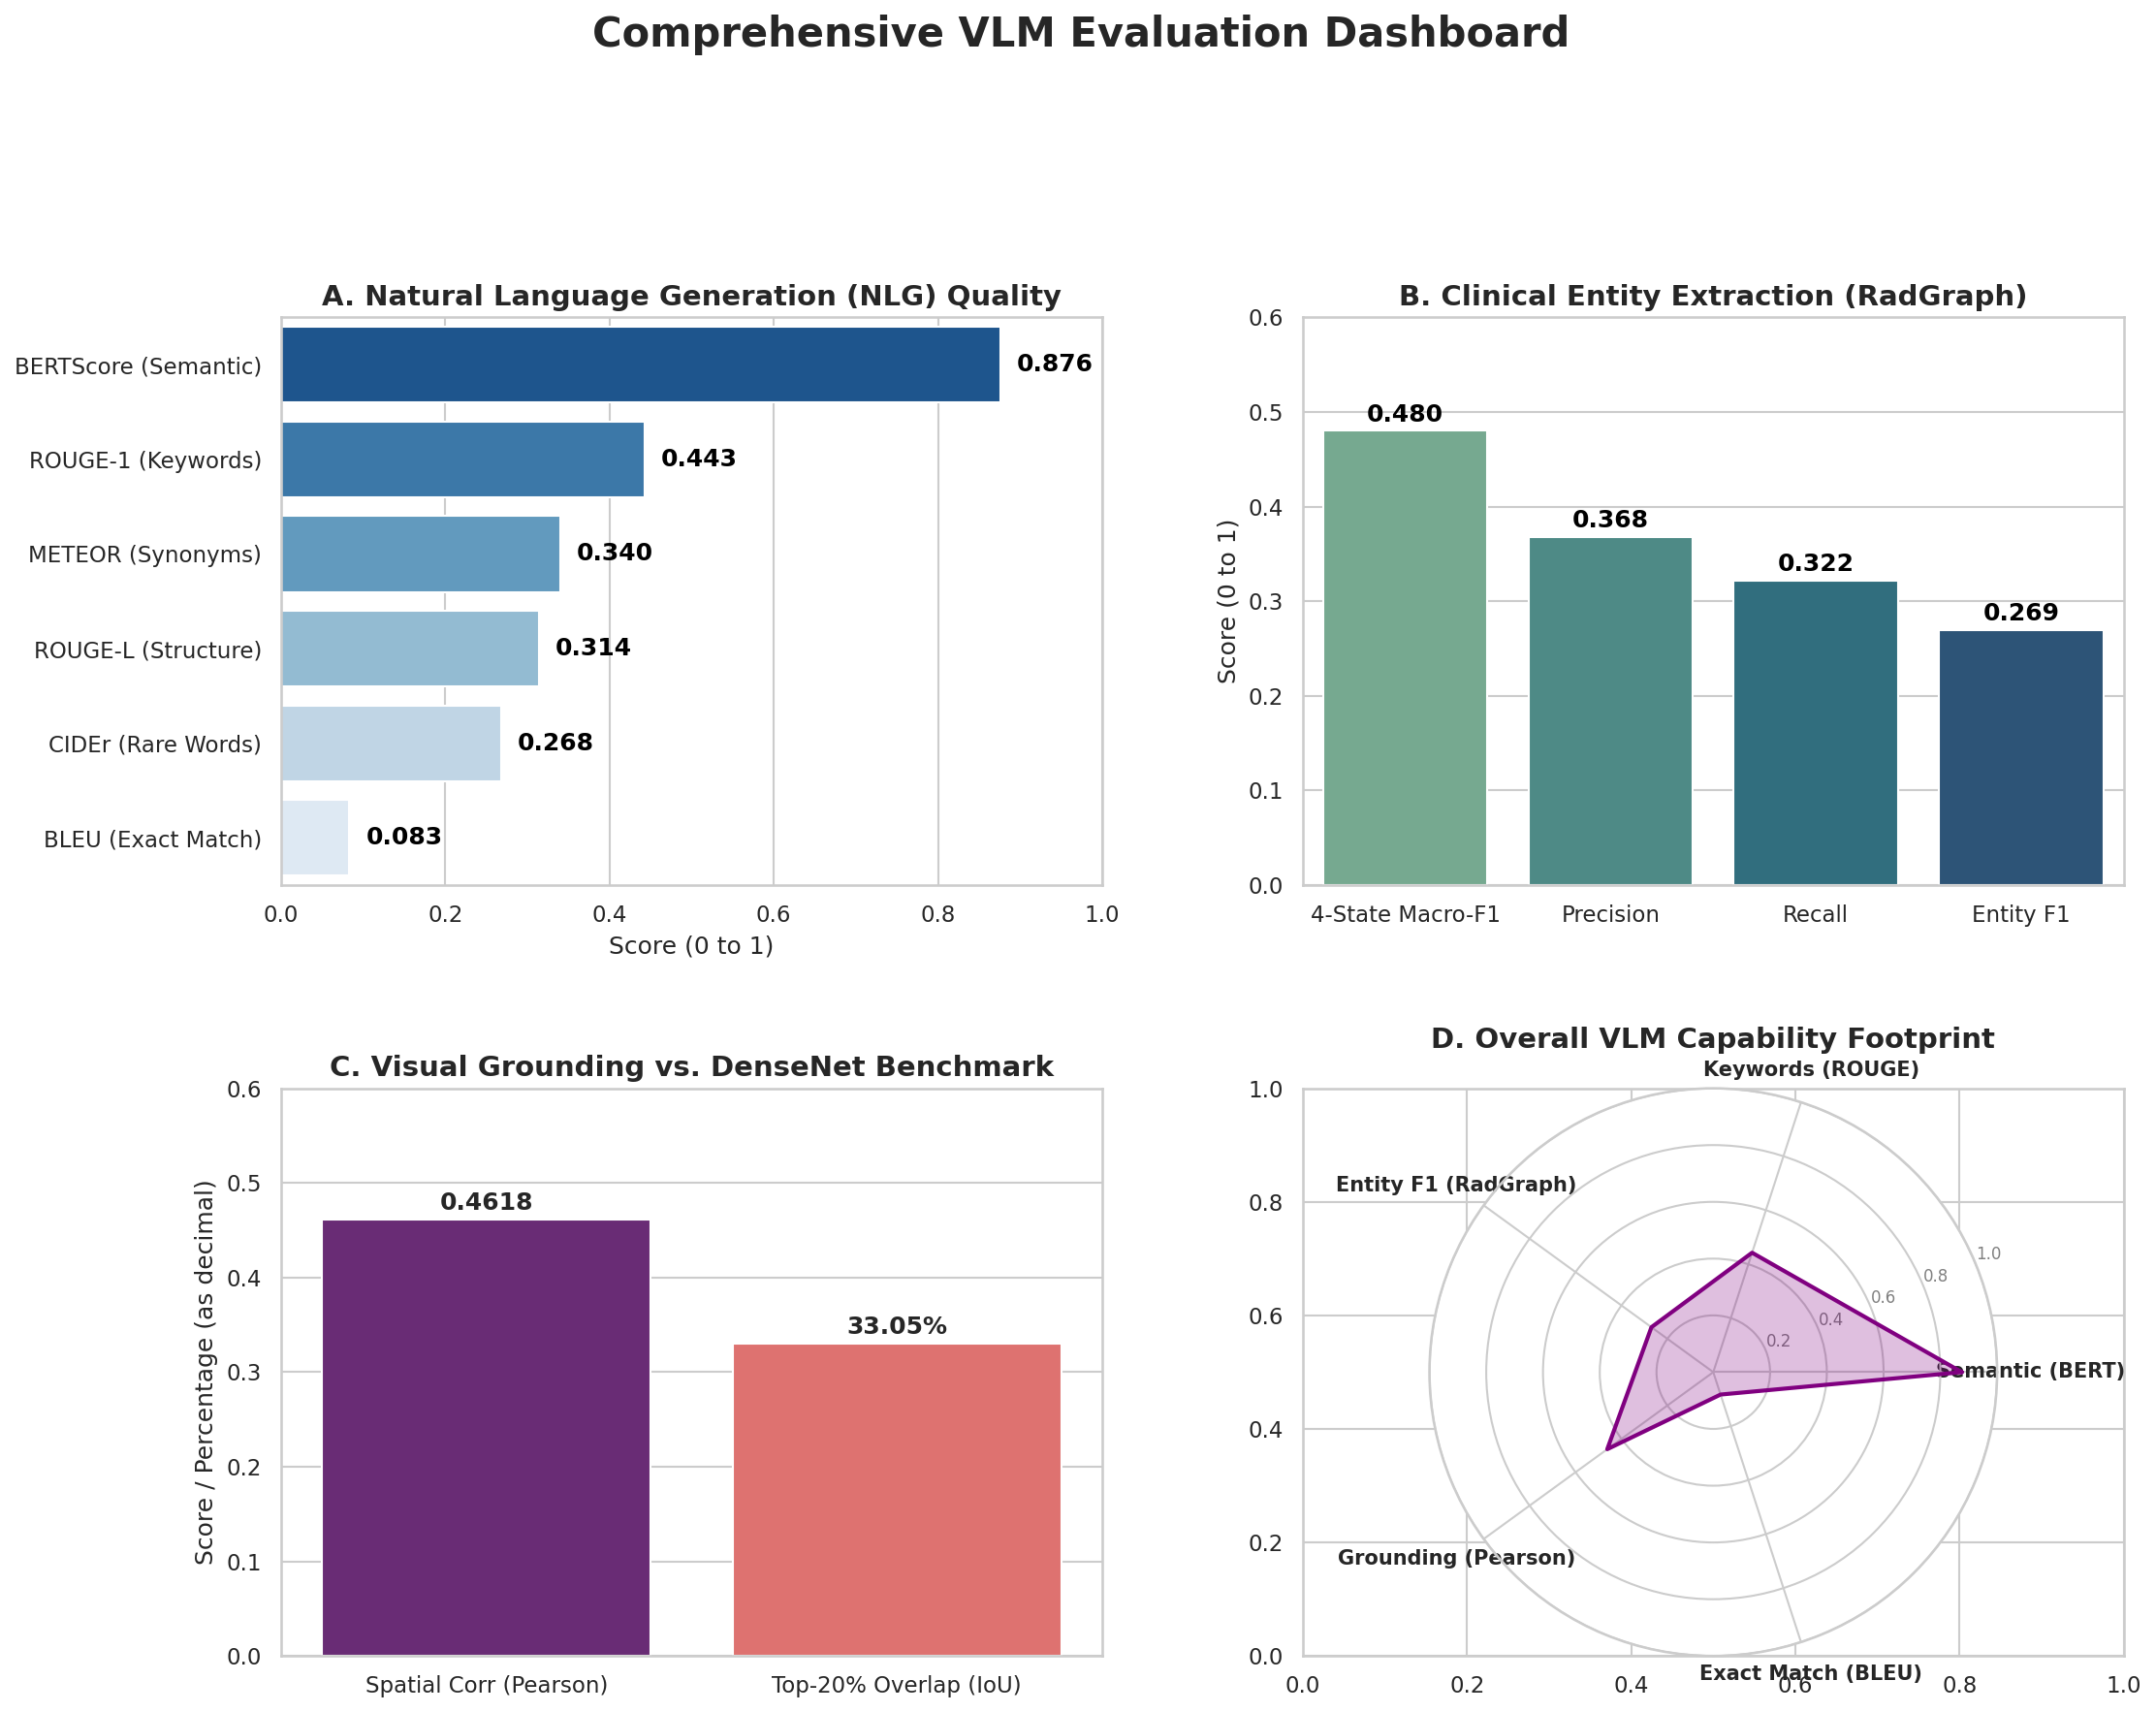

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from math import pi


# Set academic plotting style
sns.set_theme(style="whitegrid", palette="muted")

# Your exact output data
nlg_metrics = {
    'BERTScore (Semantic)': 0.8757,
    'ROUGE-1 (Keywords)': 0.4425,
    'METEOR (Synonyms)': 0.3403,
    'ROUGE-L (Structure)': 0.3141,
    'CIDEr (Rare Words)': 0.2677,
    'BLEU (Exact Match)': 0.0830
}

radgraph_metrics = {
    '4-State Macro-F1': 0.4802,
    'Precision': 0.3684,
    'Recall': 0.3222,
    'Entity F1': 0.2694
}

grounding_metrics = {
    'Spatial Corr (Pearson)': 0.4618,
    'Top-20% Overlap (IoU)': 0.3305 # Converted from 33.05% for scale matching
}

# Create a 2x2 grid of plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12), dpi=150)
fig.suptitle('Comprehensive VLM Evaluation Dashboard', fontsize=20, fontweight='bold', y=1.02)

# ==========================================
# GRAPH 1: The NLG Spectrum (Lexical vs Semantic)
# ==========================================
ax1 = axes[0, 0]
df_nlg = pd.DataFrame(list(nlg_metrics.items()), columns=['Metric', 'Score'])
# Sort descending
df_nlg = df_nlg.sort_values(by='Score', ascending=False)

sns.barplot(x='Score', y='Metric', data=df_nlg, ax=ax1, palette='Blues_r')
ax1.set_title('A. Natural Language Generation (NLG) Quality', fontsize=14, fontweight='bold')
ax1.set_xlim(0, 1.0)
ax1.set_xlabel('Score (0 to 1)')
ax1.set_ylabel('')

# Add data labels
for i, v in enumerate(df_nlg['Score']):
    ax1.text(v + 0.02, i, f"{v:.3f}", color='black', va='center', fontweight='bold')

# ==========================================
# GRAPH 2: Clinical Entity Accuracy (RadGraph)
# ==========================================
ax2 = axes[0, 1]
df_rad = pd.DataFrame(list(radgraph_metrics.items()), columns=['Metric', 'Score'])

sns.barplot(x='Metric', y='Score', data=df_rad, ax=ax2, palette='crest')
ax2.set_title('B. Clinical Entity Extraction (RadGraph)', fontsize=14, fontweight='bold')
ax2.set_ylim(0, 0.6)
ax2.set_ylabel('Score (0 to 1)')
ax2.set_xlabel('')

# Add data labels
for i, v in enumerate(df_rad['Score']):
    ax2.text(i, v + 0.01, f"{v:.3f}", color='black', ha='center', fontweight='bold')

# ==========================================
# GRAPH 3: Visual Grounding / Explainability
# ==========================================
ax3 = axes[1, 0]
df_ground = pd.DataFrame(list(grounding_metrics.items()), columns=['Metric', 'Score'])

# Using a horizontal bar chart for clarity
sns.barplot(x='Metric', y='Score', data=df_ground, ax=ax3, palette='magma')
ax3.set_title('C. Visual Grounding vs. DenseNet Benchmark', fontsize=14, fontweight='bold')
ax3.set_ylim(0, 0.6)
ax3.set_ylabel('Score / Percentage (as decimal)')
ax3.set_xlabel('')

# Add data labels (Formatting IoU as percentage)
ax3.text(0, df_ground['Score'][0] + 0.01, f"{df_ground['Score'][0]:.4f}", ha='center', fontweight='bold')
ax3.text(1, df_ground['Score'][1] + 0.01, f"{df_ground['Score'][1]*100:.2f}%", ha='center', fontweight='bold')

# ==========================================
# GRAPH 4: The VLM "Footprint" (Radar Chart)
# ==========================================

ax4 = plt.subplot(224, polar=True)

# Select key representative metrics for the "Overall Snapshot"
categories = ['Semantic (BERT)', 'Keywords (ROUGE)', 'Entity F1 (RadGraph)', 'Grounding (Pearson)', 'Exact Match (BLEU)']
values = [nlg_metrics['BERTScore (Semantic)'], nlg_metrics['ROUGE-1 (Keywords)'], radgraph_metrics['Entity F1'], grounding_metrics['Spatial Corr (Pearson)'], nlg_metrics['BLEU (Exact Match)']]

# Close the radar loop
values += values[:1]
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

# Plot the radar
ax4.plot(angles, values, linewidth=2, linestyle='solid', color='purple')
ax4.fill(angles, values, 'purple', alpha=0.25)

# Add labels
ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(categories, fontsize=10, fontweight='bold')
ax4.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax4.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], color="grey", size=8)
ax4.set_ylim(0, 1.0)
ax4.set_title('D. Overall VLM Capability Footprint', fontsize=14, fontweight='bold', pad=20)

# ==========================================
# SAVE & DISPLAY
# ==========================================
plt.tight_layout(pad=4.0)


save_path = "/content/drive/MyDrive/msc_medical_vlm_weights_final/thesis_results_dashboard.png"
plt.savefig(save_path, bbox_inches='tight', dpi=300)
print(f"✅ Dashboard successfully generated and saved to: {save_path}")

plt.show()